In [1]:
import wandb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
 
matplotlib.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    # Lines & axes
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 3,
    # Grid
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.5,
    # Layout
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    # Use Type 1 fonts for PDF/SVG (required by many journals)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})
 
# Color palette — colorblind-friendly (Wong 2011)
COLORS = ["#0072B2", "#D55E00"]  # blue, vermillion
 
 
def fetch_run_history(project: str, run_name: str, metrics: list[str]) -> dict:
    """Fetch metric history for a single run from wandb."""
    api = wandb.Api()
    runs = api.runs(project, filters={"display_name": run_name})
    matching = [r for r in runs if r.name == run_name]
    if not matching:
        raise ValueError(f"Run '{run_name}' not found in project '{project}'.")
    run = matching[0]
 
    history = run.history(keys=metrics, pandas=True)
    return history
 
 
def plot_wandb_metrics(
    project: str,
    run_names: tuple[str, str],
    metric_names: tuple[str, str, str],
    run_labels: tuple[str, str],
    metric_titles: tuple[str, str, str] | None = None,
    x_key: str = "_step",
    output_path: str = "metrics.png",
    fig_width: float = 7.0,   # inches — fits a two-column IEEE paper
    fig_height: float = 2.2,
) -> None:
    """
    Fetch three metrics from two wandb runs and plot them as side-by-side
    subplots, suitable for inclusion in an academic paper.
 
    Parameters
    ----------
    project       : wandb project path, e.g. "entity/project-name"
    run_names     : (run_name_1, run_name_2) — wandb run *names* (not IDs)
    metric_names  : (metric_1, metric_2, metric_3) logged to wandb
    run_labels    : (label_1, label_2) — human-readable legend entries
    metric_titles : optional axis titles; defaults to metric_names
    x_key         : x-axis key (default "_step"); use "_runtime" for wall time
    output_path   : path for the saved SVG file
    fig_width     : figure width in inches
    fig_height    : figure height in inches
    """
    if metric_titles is None:
        metric_titles = metric_names
 
    all_metrics = list(metric_names) + ([x_key] if x_key != "_step" else [])
 
    # --- Fetch data ---
    histories = []
    for run_name in run_names:
        print(f"Fetching '{run_name}' …")
        df = fetch_run_history(project, run_name, list(metric_names) + [x_key])
        histories.append(df)
 
    # --- Plot ---
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_width, fig_height),
        sharey=False,
    )
 
    for ax_idx, (metric, title) in enumerate(zip(metric_names, metric_titles)):
        ax = axes[ax_idx]
 
        for run_idx, (df, label) in enumerate(zip(histories, run_labels)):
            if metric not in df.columns:
                print(f"  Warning: '{metric}' not in run '{run_names[run_idx]}'.")
                continue
 
            x = df[x_key] if x_key in df.columns else np.arange(len(df))
            y = df[metric]
 
            # Drop NaNs
            mask = y.notna()
            x, y = x[mask], y[mask]
 
            ax.plot(
                x, y,
                color=COLORS[run_idx],
                label=label,
                linewidth=1.6,
                alpha=0.92,
            )
 
        ax.set_title(title, pad=4)
        ax.set_xlabel("Step" if x_key == "_step" else x_key)
        if ax_idx == 0:
            ax.set_ylabel("Value")
 
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, integer=True))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
 
        # Tight spine clipping
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
 
    # Single shared legend, placed below the subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=len(run_labels),
        bbox_to_anchor=(0.5, -0.18),
        frameon=False,
    )
 
    plt.tight_layout()
    fig.savefig(output_path, format="png")
    print(f"\nSaved → {output_path}")
 
 
# ---------------------------------------------------------------------------
# Example usage — replace with your actual values
# ---------------------------------------------------------------------------
# if __name__ == "__main__":


/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened becau

Fetching 'best_emcomm_fix_eval_BOS_add_s_t5_winoground_99th_better_temp_tf_more_capacity' …
Fetching 'only_5_epochs_full' …

Saved → metrics.png


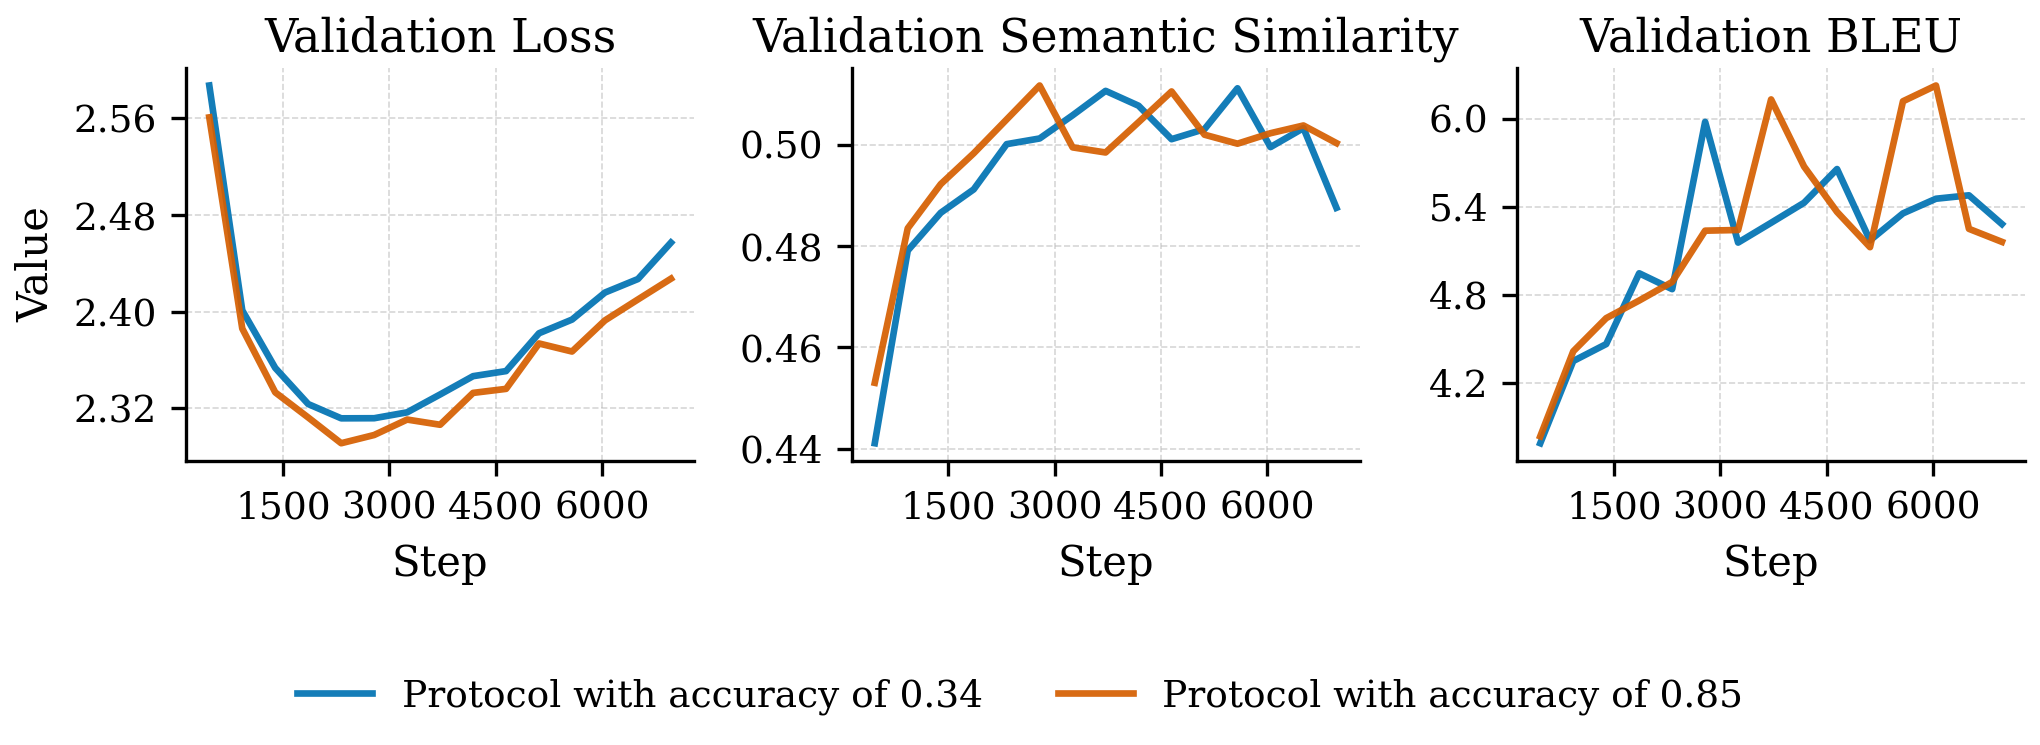

In [3]:
plot_wandb_metrics(
    project="nipg-elte/EmComm-Caption-Translator",
    run_names=("best_emcomm_fix_eval_BOS_add_s_t5_winoground_99th_better_temp_tf_more_capacity", "only_5_epochs_full"),
    metric_names=("val/loss", "val/semantic_similarity",  "val/bleu"),
    run_labels=("Protocol with accuracy of 0.34", "Protocol with accuracy of 0.85"),
    metric_titles=("Validation Loss", "Validation Semantic Similarity", "Validation BLEU"),
    x_key="_step",
    output_path="metrics.png",
)